# Geoloc

## infos
ligne 42368 : photo id 5464485473, correction -> les dates étaient décalée, le # de minutes (25) était collé au titre de la photo ("une lundi matin comme tout les autre ;-(") et le décalage était propagé.

pour les autres, on enleve les 142 lignes qui ont des valeurs non-nulles qui dépassent les colonnes attendues. (unnamed 16, y'a aussi 2 lignes avec des valeurs dans unnamed 18 mais elles sont comptabilisées dans les autres)

In [1]:
import numpy as np
import pandas as pd
import folium as fl
import plotly.express as px

In [2]:
read_data = pd.read_csv("../flickr_data2.csv")
read_data.drop_duplicates()
read_data.head()

C:\Users\Pyta\AppData\Local\Temp\ipykernel_37312\2441036979.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  read_data = pd.read_csv("../flickr_data2.csv")


,id,user,lat,long,tags,title,date_taken_minute,date_taken_hour,date_taken_day,date_taken_month,date_taken_year,date_upload_minute,date_upload_hour,date_upload_day,date_upload_month,date_upload_year,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,4395181099,30624617@N03,45.754858,4.821710,"chair,lyon,rhône,chaise,rhônealpes",Chaises avec vue,11.0,15,28,2,2010,23,20,28.0,2,2010.0,NaN,NaN,NaN
1,4394748717,35853470@N00,45.753270,4.862953,NaN,NaN,51.0,17,28,2,2010,52,17,28.0,2,2010.0,NaN,NaN,NaN
2,4394694699,11817998@N05,45.760655,4.846564,"365,iphone",59/365 - R46 V103 B163,29.0,17,28,2,2010,33,17,28.0,2,2010.0,NaN,NaN,NaN
3,4394803790,11545749@N06,45.784000,4.874072,"nin,nineinchnails,gift,screening,toiou,avott",2010-01-29 Toiou Avott Lyon,15.0,20,28,1,2010,38,12,28.0,2,2010.0,NaN,NaN,NaN
4,4394803554,11545749@N06,45.784000,4.874072,"lyon,nin,nineinchnails,gift,screening,toiou,avott",2010-01-28 Toiou Avott Lyon,10.0,20,28,1,2010,38,12,28.0,2,2010.0,NaN,NaN,NaN


In [30]:
wrong_data = read_data.dropna(how="all", subset=read_data.columns[[16, 18]])
fix_data = read_data.drop(index=wrong_data.index, axis=1)
toDropColumns = read_data.columns[[16, 17, 18]]
fix_data = fix_data.drop(toDropColumns, axis=1)
tagsfix_data = fix_data.dropna(how="all", subset=[" tags"])

len(read_data) - len(fix_data)

142

In [4]:
print(len(fix_data))
data2D = fix_data[[' lat', ' long']]
data2D.head()

420098


,lat,long
0,45.754858,4.821710
1,45.753270,4.862953
2,45.760655,4.846564
3,45.784000,4.874072
4,45.784000,4.874072


## Partie sur la carte.

In [5]:
map = fl.Map(location=(45.757778, 4.832222), zoom_start = 13)

In [6]:
fl.Marker(
    location=[45.757778, 4.832222],
    tooltip="Clique moi !",
    popup="Centre de Lyon<br>(selon wikipedia)",
    icon=fl.Icon(icon_color="white", icon="info-sign", color="red"),
).add_to(map)

fl.Marker(
    location=[45.781883, 4.872814],
    tooltip="Clique moi !",
    popup="Ada Lovelace<br>(notre bâtiment)",
    icon=fl.Icon(icon_color="white", icon="book", color="blue"),
).add_to(map)

In [7]:
trail_coordinates = [
    (45.757778, 4.832222),
    (45.765482, 4.852781),
    (45.781883, 4.872814),
]

fl.PolyLine(trail_coordinates, tooltip="Coast", color="green").add_to(map)

In [8]:
map.save("test.html")

## Clustering avec K-Means

Première implémentation d'un algorithme de clustering simple basé sur les coordonnées géographiques.


In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Extraire les coordonnées géographiques
donnees_geoloc = fix_data[[' lat', ' long']].copy()

print(f"Nombre de points avec coordonnées: {len(donnees_geoloc)}")
print(f"Latitude - min: {donnees_geoloc[' lat'].min()}, max: {donnees_geoloc[' lat'].max()}")
print(f"Longitude - min: {donnees_geoloc[' long'].min()}, max: {donnees_geoloc[' long'].max()}")

# Appliquer K-Means avec k=25
nombre_clusters = 25
kmeans = KMeans(n_clusters=nombre_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(donnees_geoloc)

donnees_geoloc_avec_clusters = donnees_geoloc.copy()
donnees_geoloc_avec_clusters['cluster'] = clusters

print(f"\nClusters créés: {nombre_clusters}")
print("\nDistribution des points par cluster:")
print(donnees_geoloc_avec_clusters['cluster'].value_counts().sort_index())


Nombre de points avec coordonnées: 420098
Latitude - min: 45.6552, max: 45.85495
Longitude - min: 4.720312, max: 5.006709


c:\Users\Pyta\anaconda3\envs\DataMiningV2\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)



Clusters créés: 25

Distribution des points par cluster:
cluster
0     71437
1     10132
2     37700
3     10767
4     30602
5      2161
6      4540
7     11815
8      2876
9     26071
10     8584
11     4065
12     3236
13    23056
14     2716
15     1773
16    56044
17     9549
18    14703
19     1481
20    76320
21     3610
22     1447
23     3156
24     2257
Name: count, dtype: int64


## Optimisation de la valeur de K pour le KMeans avec la méthode du coude

Avec la méthode du coude, nous essayerons de trouver la meilleure valeur de k

In [10]:
from sklearn.cluster import KMeans

In [11]:
range_k = range(1, 50)
inertias = []
for i in range_k:
    # apply KMeans with i clusters
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=3)
    kmeans.fit(data2D)
    inertias.append(kmeans.inertia_)



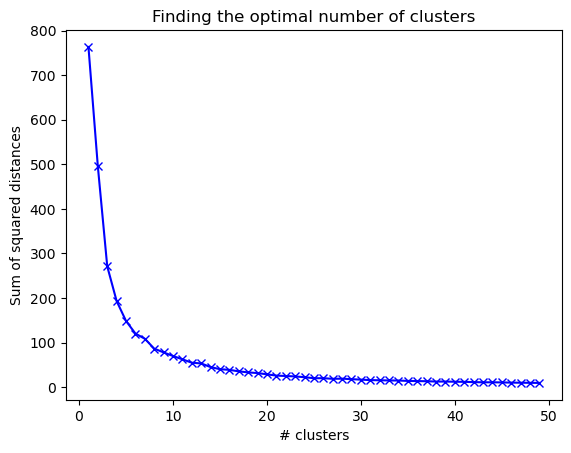

In [12]:
# Visualisation

n = len(inertias)
xticks_new = np.arange(1, n+1)
plt.plot(xticks_new, inertias[0:n], 'bx-')
plt.title('Finding the optimal number of clusters')
plt.xlabel('# clusters')
plt.ylabel('Sum of squared distances')
plt.show()

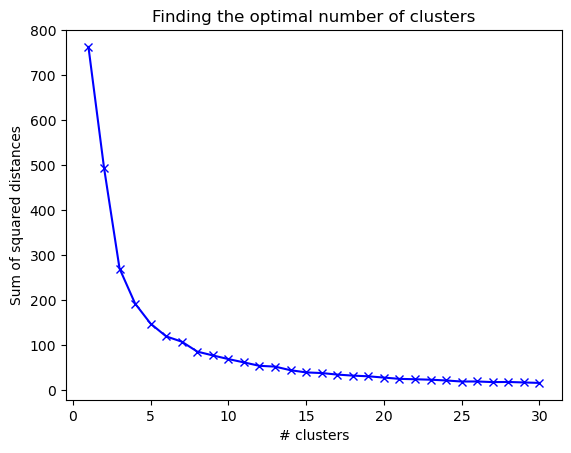

In [13]:
# Visualisation

n = 30
xticks_new = np.arange(1, n+1)
plt.plot(xticks_new, inertias[0:n], 'bx-')
plt.title('Finding the optimal number of clusters')
plt.xlabel('# clusters')
plt.ylabel('Sum of squared distances')
plt.show()

## Validation de k=50 avec la méthode du silhouette score

Après avoir trouvé k=50 avec la méthode du coude, on vérifie ce choix avec le silhouette score.


In [14]:
# Appliquer K-Means avec k=25 (choisi par la méthode du coude)
nombre_clusters = 25
kmeans = KMeans(n_clusters=nombre_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(data2D)

donnees_geoloc_avec_clusters = data2D.copy()
donnees_geoloc_avec_clusters['cluster'] = clusters

print(f"Clusters créés: {nombre_clusters}")
print("\nDistribution des points par cluster:")
print(donnees_geoloc_avec_clusters['cluster'].value_counts().sort_index())


Clusters créés: 25

Distribution des points par cluster:
cluster
0     71437
1     10132
2     37700
3     10767
4     30602
5      2161
6      4540
7     11815
8      2876
9     26071
10     8584
11     4065
12     3236
13    23056
14     2716
15     1773
16    56044
17     9549
18    14703
19     1481
20    76320
21     3610
22     1447
23     3156
24     2257
Name: count, dtype: int64


In [15]:
labels = kmeans.labels_
print(f"k-means labels : {labels}")

k-means labels : [ 7 10 13 ... 16 16 16]


In [16]:
donnees_geoloc_avec_clusters['cluster'] = labels
donnees_geoloc_avec_clusters.head()

,lat,long,cluster
0,45.754858,4.821710,7
1,45.753270,4.862953,10
2,45.760655,4.846564,13
3,45.784000,4.874072,18
4,45.784000,4.874072,18


In [17]:
from sklearn.metrics import silhouette_score, silhouette_samples

In [18]:
labels = kmeans.labels_

silhouette_avg = silhouette_score(data2D, labels, metric='euclidean')
sample_silhouette_values = silhouette_samples(data2D, labels, metric='euclidean')

print(f"Silhouette score moyen pour k=25: {silhouette_avg:.3f}")
print(f"\nInterprétation:")
if silhouette_avg > 0.5:
    print(" Excellent: Les clusters sont bien séparés et cohésifs")
elif silhouette_avg > 0.4:
    print(" Bon: Les clusters sont correctement formés")
elif silhouette_avg > 0.25:
    print(" Moyen: La structure des clusters est faible")
else:
    print("Mauvais: Les clusters ne sont pas bien définis")


KeyboardInterrupt: 

In [19]:
import numpy as np
from sklearn.metrics import silhouette_score, silhouette_samples

sample_size = 5000  
indices = np.random.choice(len(data2D), sample_size, replace=False)

x_sample = data2D.iloc[indices]
labels_sample = labels[indices]

sample_silhouette_values = silhouette_samples(
    x_sample,
    labels_sample,
    metric="euclidean"
)

silhouette_avg = sample_silhouette_values.mean()
print(f"Silhouette score moyen pour k=50: {silhouette_avg:.3f}")
print(f"\nInterprétation:")
if silhouette_avg > 0.5:
    print(" Excellent: Les clusters sont bien séparés et cohésifs")
elif silhouette_avg > 0.4:
    print(" Bon: Les clusters sont correctement formés")
elif silhouette_avg > 0.25:
    print(" Moyen: La structure des clusters est faible")
else:
    print("Mauvais: Les clusters ne sont pas bien définis")

Silhouette score moyen pour k=50: 0.527

Interprétation:
 Excellent: Les clusters sont bien séparés et cohésifs


## Clustering avec DBSCAN 

On applique le clustering avec DBSCAN

In [20]:
from sklearn.cluster import DBSCAN

In [21]:
min_pts = 4

In [22]:
from sklearn.neighbors import NearestNeighbors

In [23]:
def find_optimal_eps(data, min_pts):
    # Calculer les distances
    neigh = NearestNeighbors(n_neighbors=min_pts)
    neigh.fit(data)
    distances, _ = neigh.kneighbors(data)

    # Sort les distances
    k_distances = np.sort(distances[:, min_pts - 1])

    # Create plot avec matplotlib
    plt.figure(figsize=(10, 6))
    plt.plot(k_distances, 'b-')
    plt.ylabel(f'Distance to {min_pts}th nearest neighbor')
    plt.xlabel('Points sorted by distance')
    plt.title(f'K-distance Graph (k={min_pts})')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return k_distances


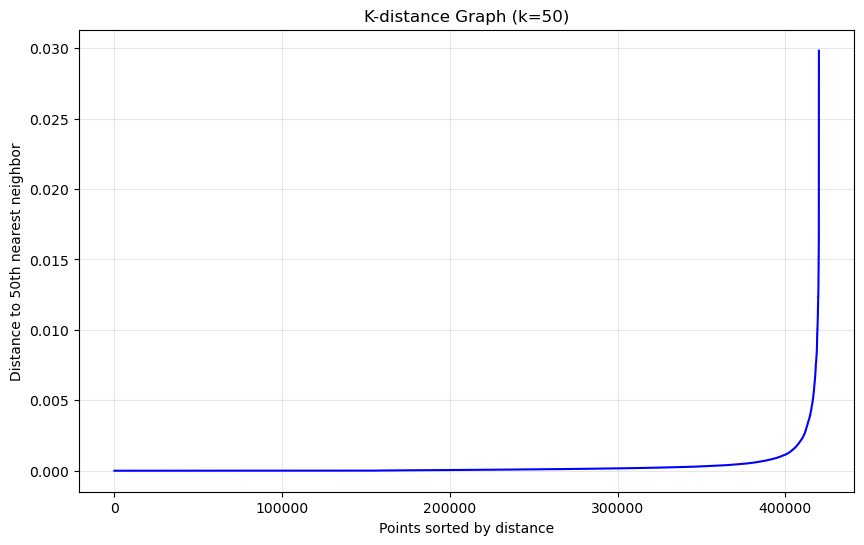


Distance médiane: 0.000058
Distance 75e percentile: 0.000197
Distance 90e percentile: 0.000529

Suggestion: utiliser eps entre 0.000197 et 0.000529


In [24]:
k_distances = find_optimal_eps(data2D, min_pts=50)

# Afficher quelques valeurs suggérées
print(f"\nDistance médiane: {np.median(k_distances):.6f}")
print(f"Distance 75e percentile: {np.percentile(k_distances, 75):.6f}")
print(f"Distance 90e percentile: {np.percentile(k_distances, 90):.6f}")
print(f"\nSuggestion: utiliser eps entre {np.percentile(k_distances, 75):.6f} et {np.percentile(k_distances, 90):.6f}")


## Appliquer DBScan avec les bons paramètres

In [25]:
best_eps = 30
best_min_samples = 100
# Appliquer DBScan
best_dbscan = DBSCAN(eps = best_eps, min_samples=best_min_samples, metric='haversine')
best_labels = best_dbscan.fit_predict(data2D)


MemoryError: 

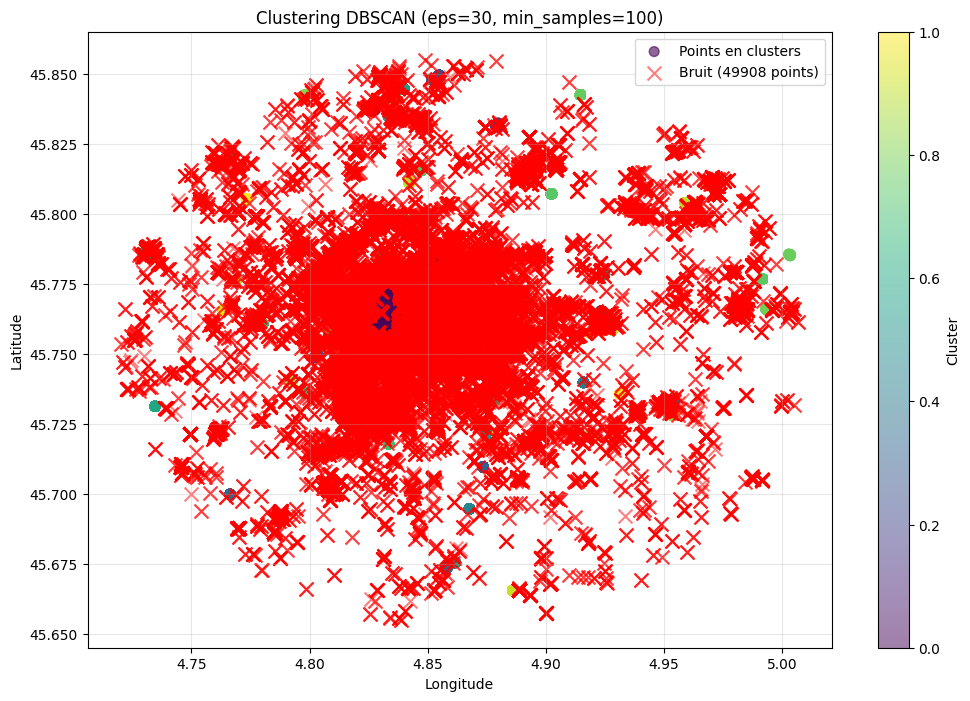


Distribution des points par cluster:
Cluster 0: 384 points
Cluster 1: 690 points
Cluster 2: 33212 points
Cluster 3: 13383 points
Cluster 4: 44188 points
Cluster 5: 19920 points
Cluster 6: 45201 points
Cluster 7: 35897 points
Cluster 8: 9289 points
Cluster 9: 398 points
Cluster 10: 279 points
Cluster 11: 10297 points
Cluster 12: 6373 points
Cluster 13: 5405 points
Cluster 14: 229 points
Cluster 15: 201 points
Cluster 16: 4015 points
Cluster 17: 2963 points
Cluster 18: 16389 points
Cluster 19: 829 points
Cluster 20: 481 points
Cluster 21: 1375 points
Cluster 22: 1600 points
Cluster 23: 259 points
Cluster 24: 9069 points
Cluster 25: 2150 points
Cluster 26: 489 points
Cluster 27: 2800 points
Cluster 28: 11120 points
Cluster 29: 346 points
Cluster 30: 604 points
Cluster 31: 2113 points
Cluster 32: 914 points
Cluster 33: 972 points
Cluster 34: 418 points
Cluster 35: 96 points
Cluster 36: 854 points
Cluster 37: 138 points
Cluster 38: 785 points
Cluster 39: 462 points
Cluster 40: 445 points
C

In [ ]:
# Visualiser les clusters DBSCAN
plt.figure(figsize=(12, 8))

# Séparer les points en cluster et les outliers
is_noise = best_labels == -1
is_cluster = best_labels != -1

# Tracer les points des clusters
if is_cluster.sum() > 0:
    scatter = plt.scatter(donnees_geoloc.loc[is_cluster, ' long'],
                         donnees_geoloc.loc[is_cluster, ' lat'],
                         c=best_labels[is_cluster],
                         cmap='viridis',
                         alpha=0.6,
                         s=50,
                         label='Points en clusters')

# Tracer les outliers en noir
if is_noise.sum() > 0:
    plt.scatter(donnees_geoloc.loc[is_noise, ' long'],
               donnees_geoloc.loc[is_noise, ' lat'],
               c='red',
               marker='x',
               s=100,
               alpha=0.5,
               label=f'Bruit ({is_noise.sum()} points)')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Clustering DBSCAN (eps={best_eps}, min_samples={best_min_samples})')
plt.legend()
plt.grid(True, alpha=0.3)
if is_cluster.sum() > 0:
    plt.colorbar(label='Cluster')
plt.show()

print(f"\nDistribution des points par cluster:")
unique, counts = np.unique(best_labels[is_cluster], return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"Cluster {cluster_id}: {count} points")


In [ ]:
# Analyser les résultats
n_clusters = len(set(best_labels)) - (1 if -1 in best_labels else 0)
n_noise = list(best_labels).count(-1)

print(f"Paramètres DBSCAN:")
print(f"  eps: {best_eps}")
print(f"  min_samples: {best_min_samples}")
print(f"\nRésultats:")
print(f"  Nombre de clusters: {n_clusters}")
print(f"  Nombre de points de bruit (outliers): {n_noise}")
print(f"  Pourcentage de bruit: {100*n_noise/len(donnees_geoloc):.1f}%")
print(f"  Nombre de points en clusters: {len(donnees_geoloc) - n_noise}")


Paramètres DBSCAN:
  eps: 30
  min_samples: 100

Résultats:
  Nombre de clusters: 212
  Nombre de points de bruit (outliers): 49908
  Pourcentage de bruit: 11.9%
  Nombre de points en clusters: 370190


## Teste du clustering avec HDBSCAN

In [ ]:
import numpy as np

In [ ]:
coords_rad = np.radians(data2D)
coords_rad.head()

,lat,long
0,0.798573,0.084155
1,0.798545,0.084875
2,0.798674,0.084588
3,0.799082,0.085069
4,0.799082,0.085069


In [ ]:
import hdbscan

In [ ]:

clusterer = hdbscan.HDBSCAN(min_cluster_size = 100, min_samples = 50, metric= 'haversine')
labels = clusterer.fit_predict(coords_rad)
df = donnees_geoloc.copy()
df["cluster"] = labels
pois = (
    df[df.cluster != -1]
    .groupby("cluster")
    .agg(
        lat_mean=(" lat", "mean"),
        lon_mean=(" long", "mean"),
        nb_photos=("cluster", "count")
    )
    .sort_values("nb_photos", ascending=False)
)

In [26]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
plt.figure(figsize=(10, 10))
# Prendre un échantillon pour la visualisation
sample_size = 2000
indices = np.random.choice(len(coords_rad), sample_size, replace=False)
coords_rad_sample = coords_rad.iloc[indices].values
labels_sample = labels[indices]

# Bruit
mask_noise = labels_sample == -1
plt.scatter(
    coords_rad_sample[mask_noise, 1],
    coords_rad_sample[mask_noise, 0],
    s=1,
    c='lightgrey',
    alpha=0.4,
    label='Bruit'
)

# Clusters
mask_cluster = labels_sample != -1
plt.scatter(
    coords_rad_sample[mask_cluster, 1],
    coords_rad_sample[mask_cluster, 0],
    s=2,
    c=labels_sample[mask_cluster],
    cmap='tab20',
    alpha=0.8
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("HDBSCAN – Clusters géographiques (échantillon)")
plt.legend(markerscale=5)
plt.show()


NameError: name 'coords_rad' is not defined

<Figure size 1000x1000 with 0 Axes>

In [ ]:
# Créer une carte avec les clusters HDBSCAN
import folium
from folium import plugins

# Réinitialiser les indices pour éviter les problèmes
donnees_geoloc_reset = donnees_geoloc.reset_index(drop=True)
labels_reset = labels.copy()

# Créer la carte centrée sur Lyon
map_hdbscan = folium.Map(
    location=[45.757778, 4.832222],
    zoom_start=12
)

# Couleurs pour les clusters
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 
          'darkblue', 'darkgreen', 'cadetblue', 'darkpurple', 'white', 'pink', 'gray']

# Ajouter les points avec les couleurs des clusters
for idx in range(len(donnees_geoloc_reset)):
    cluster_id = labels_reset[idx]
    row = donnees_geoloc_reset.iloc[idx]
    
    # Sauter le bruit (cluster -1)
    if cluster_id == -1:
        continue
    
    # Choisir la couleur selon le cluster
    color = colors[int(cluster_id) % len(colors)]
    
    # Ajouter un marqueur
    folium.CircleMarker(
        location=[row[' lat'], row[' long']],
        radius=3,
        popup=f'Cluster {cluster_id}',
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7,
        weight=1
    ).add_to(map_hdbscan)

# Ajouter les points de bruit en gris transparent
for idx in range(len(donnees_geoloc_reset)):
    if labels_reset[idx] == -1:
        row = donnees_geoloc_reset.iloc[idx]
        folium.CircleMarker(
            location=[row[' lat'], row[' long']],
            radius=1,
            popup='Bruit',
            color='gray',
            fill=True,
            fillColor='gray',
            fillOpacity=0.2,
            weight=0.5
        ).add_to(map_hdbscan)

# Ajouter les centres des clusters (POIs)
for cluster_id, poi_row in pois.iterrows():
    folium.Marker(
        location=[poi_row['lat_mean'], poi_row['lon_mean']],
        popup=f"Cluster {cluster_id}<br>{int(poi_row['nb_photos'])} photos",
        icon=folium.Icon(color=colors[int(cluster_id) % len(colors)], icon='info-sign')
    ).add_to(map_hdbscan)

# Sauvegarder la carte
map_hdbscan.save('map_hdbscan.html')
print("Carte HDBSCAN sauvegardée dans 'map_hdbscan.html'")
print(f"\nRésumé des clusters HDBSCAN:")
print(pois)


Carte HDBSCAN sauvegardée dans 'map_hdbscan.html'

Résumé des clusters HDBSCAN:
          lat_mean  lon_mean  nb_photos
cluster                                
91       45.837448  4.826248      11488
87       45.837545  4.826130       7433
89       45.837410  4.826163       6773
318      45.765606  4.849185       3537
618      45.760806  4.835692       3094
...            ...       ...        ...
526      45.760453  4.820177        100
708      45.762773  4.831262        100
541      45.766124  4.824712        100
851      45.762030  4.827038        100
521      45.752547  4.835391        100

[882 rows x 3 columns]


## NLP


In [ ]:
clean_df = tagsfix_data

print(len(clean_df[' tags']))

In [ ]:
import re
nonatags_df = clean_df[' tags']
count = nonatags_df.apply(lambda x: len(re.findall(r'[^\W\d_]{2,}', str(x)))).sum()

print(f"Number of tags in the cleaned dataset: {count}")
print(nonatags_df)

In [ ]:
idf={}  # Inverse Document Frequency dictionary
total_docs = len(nonatags_df)
filtered_tags=["cospla","japa","feminicide","girl","hair","overwatch","tracer","aplusphoto","view","fiume","night","chaise","chair","iphone","streetphotography","rue","gens","nuit","francia","poste","river","notte","night"]
for tags in nonatags_df:
    unique_tags = set(re.findall(r'[^\W\d_]{2,}', str(tags)))
    
    unique_tags = {tag.lower() for tag in unique_tags if not any(bad in tag for bad in filtered_tags)}  # Normalize to lowercase
    for tag in unique_tags:
        idf[tag] = idf.get(tag, 0) + 1
for tag in idf:
    idf[tag] = total_docs / idf[tag]
print("IDF values for tags:")
for tag, value in idf.items():
    print(f"{tag}: {value}")

In [ ]:
#Cleaning by the lower IDF values

threshold = 18  # Default threshold
filtered_tags = []

idf = {tag: value for tag, value in idf.items() if value >= threshold}
count= len(idf)
print(f"Number of tags after filtering with threshold {threshold}: {count}")
print("IDF values for tags:")
for tag, value in idf.items():
    print(f"{tag}: {value}")

In [ ]:
idf_2={}  # Inverse Document Frequency dictionary
total_docs = len(nonatags_df)
print(f"Total documents for recalculating IDF: {total_docs}")
for tags in nonatags_df:
    unique_tags = set(re.findall(r'[^\W\d_]+', str(tags)))

    for tag in unique_tags:
        if tag in idf:
            idf_2[tag] = idf_2.get(tag, 0) + 1
for tag in idf_2:
    idf_2[tag] = total_docs / idf_2[tag]

sortIDF= sorted(idf_2.items(),key=lambda x: x[1])
print("IDF values for tags:")
for tag in sortIDF:
    print(f"{tag}")